# 60 TPD Melter — How We Reach the 2% SFC Target

### Insights from your furnace data, what the recommenders deliver, and why a plant trial is the next step

**Furnace:** 60 TPD flint melter (lines S09, S10, S11, S12) · **Scope:** melter natural gas, barrier boost and melter boost · **Data:** 15-minute analytical record, 1 Sep 2025 – 30 Sep 2026 (the corrected file of 5 Oct 2026) and the 1-minute crown thermocouple

---

## The message in brief
1. **Your baseline is confirmed from raw data:** 1,576.6 kcal/kg, against your stated 1,576.3. The target is **1,544.8 kcal/kg**, i.e. −2% within each draw band or −2% draw-adjusted.
2. **Three things decide SFC:**
   - **draw** (the biggest effect)
   - **furnace ageing** (a slow drift)
   - **how gas, air and barrier boost are set** (the part we can improve)
3. **The data shows three clear sources of avoidable energy:**
   - gas is corrected **late** when gas quality (NCV) changes
   - **more barrier boost than needed** is used to hold the bottom temperature
   - slightly **more combustion air** than the furnace's best days
4. **Two recommenders** (gas + air every reversal cycle, barrier boost every hour) remove these losses.
   - Replayed on your history, they lower SFC **in every month**: about **1.3%** in Jun–Aug 2026 and **0.9%** over Dec 2025 – Sep 2026.
   - Every setpoint stays inside the furnace's proven operating range.
5. **The rest of the way to −2%** needs a few setpoint changes that history can't prove, because the furnace has never run there: a slightly lower bottom-temperature target, less air with an O₂ check, and a 1–2 °C lower crown setpoint. These are tested safely in a **phased plant trial** with daily quality checks.

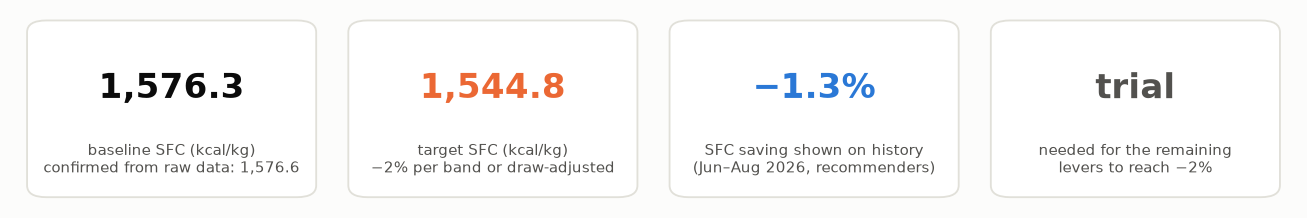

In [1]:
import report as R
R.setup()
D = R.Data()
R.kpi_tiles([('1,576.3', 'baseline SFC (kcal/kg)\nconfirmed from raw data: 1,576.6', R.INK),
             ('1,544.8', 'target SFC (kcal/kg)\n−2% per band or draw-adjusted', R.ORANGE),
             ('−1.3%', 'SFC saving shown on history\n(Jun–Aug 2026, recommenders)', R.BLUE),
             ('trial', 'needed for the remaining\nlevers to reach −2%', R.INK2)])

---
## Terms used in this notebook
| Term | Meaning |
|---|---|
| **SFC** (specific fuel consumption) | Energy used per kg of glass: `[Σ(NG × NCV) + (barrier kWh + melter kWh) × 860] ÷ draw` in kcal/kg. Lower is better |
| **NG** | Natural gas flow to the melter (common header for both ports), in the same unit as your DCS / workbook |
| **NCV** | Net calorific value of the gas: kcal per SCM. It changes every 15 minutes |
| **Draw** | Glass pulled per day, in tonnes (t/day) |
| **Barrier boost** | Electrodes low in the melter that heat the glass from below (kWh) |
| **Melter boost** | A second set of electrodes, kept on a few fixed levels (kWh) |
| **MB3** | Bottom thermocouple 3 in the melter (°C) |
| **Optical crown temperature** | Pyrometer reading of the crown, typed hourly (°C) |
| **Secondary air** | Combustion air sent with the gas through the firing port |
| **AFR** (air-fuel ratio) | Secondary air ÷ NG |
| **Air per Mcal** | Secondary air per Mcal of gas heat. It tells you how much *excess* air is used, whatever the NCV |
| **Usable day** | A day with a working NCV meter (≥ 90% valid readings), complete gas and boost data, and a draw value |
| **5-t draw band** | Days grouped by draw: 45–50, 50–55, 55–60, 60–65 t. Each band has its own baseline SFC |
| **Draw-adjusted %** | Energy compared with what the baseline period needed **at the same draw and cullet**. 0% = baseline performance; −2% = target met |
| **Furnace ageing** | Slow loss of efficiency (refractory, regenerators), visible as more energy at the same draw over the months |
| **P1–P99 (historical limits)** | The range that covers 98% of the furnace's own history. The recommenders never go outside it |
| **Walk-forward test** | Each day is recommended using only the days *before* it, exactly as in live use. No future information is used |
| **Recommender** | A calculation that tells the operator what to set (gas, air, boost) from the current conditions |

---
## 1. The data we used
We used your 15-minute analytical record and the 1-minute crown thermocouple. A day is used only when the **NCV meter worked** (at least 90% valid readings; zeros and spikes are removed) and gas and boost data are complete. **Your workbook values are not used as inputs:** every number is recomputed from the raw data, and the workbook is only used to check our numbers.

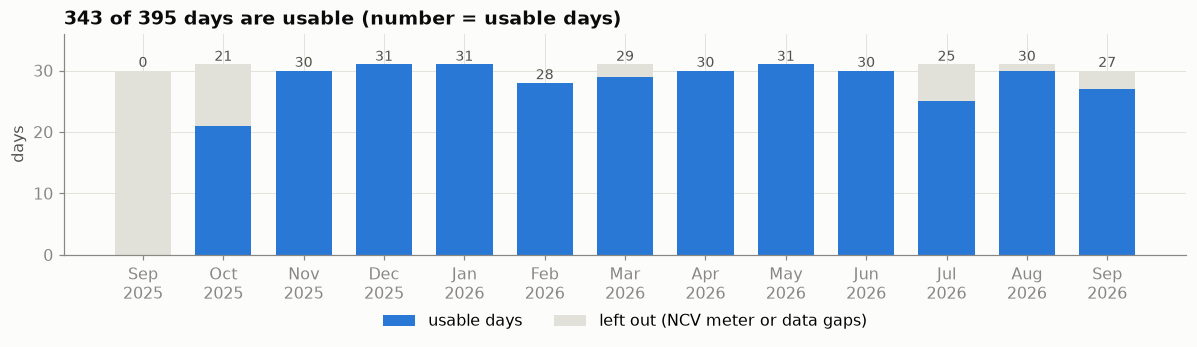

In [2]:
R.chart_coverage(D)

**Reading the chart**
- **Sep 2025** can't be used: the NCV meter read zero for the whole month.
- Every other month is almost fully usable, including **Sep 2026**, which we kept as an extra check month.

**Data notes for your team**
- On **1 Oct 2025, 1 Jun 2026 and 1 Sep 2026** the daily draw is about twice the normal value (two SAP entries added together). We halve it automatically; the corrected values for the first two dates match your SAP draw exactly. Please check the month-start draw extract.
- The corrected optical log you sent on 5 Oct 2026 fixed the date and 12-hour-clock issues. Thank you.

---
## 2. Insight 1 — Your baseline is confirmed
We recomputed SFC for every day from the raw 15-minute data, with your formula (gas heat summed per 15 minutes, using the NCV of that interval).

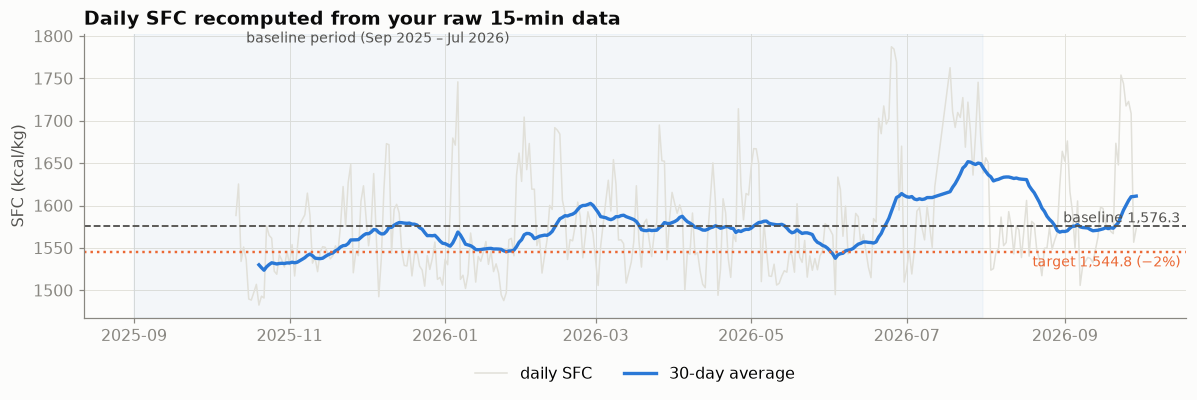

Baseline period, our average daily SFC: 1576.6 kcal/kg (your figure: 1,576.3) | target: 1,544.8


In [3]:
R.chart_baseline(D)
b = D.u[D.u.in_baseline]
print('Baseline period, our average daily SFC: %.1f kcal/kg (your figure: 1,576.3) | target: 1,544.8' % b.sfc.mean())

**What it means:** our raw-data baseline (1,576.6) and yours (1,576.3) agree, so **1,544.8 kcal/kg is the number to beat**. Daily SFC moves between about 1,480 and 1,790 kcal/kg. The next sections explain why.

---
## 3. Insight 2 — Draw is the biggest driver of SFC
A furnace loses a lot of heat through the crown, walls, regenerators and flue **whatever it melts**. Only the heat needed to melt each extra tonne grows with draw. So when draw drops, those fixed losses are spread over fewer kilograms and SFC rises.

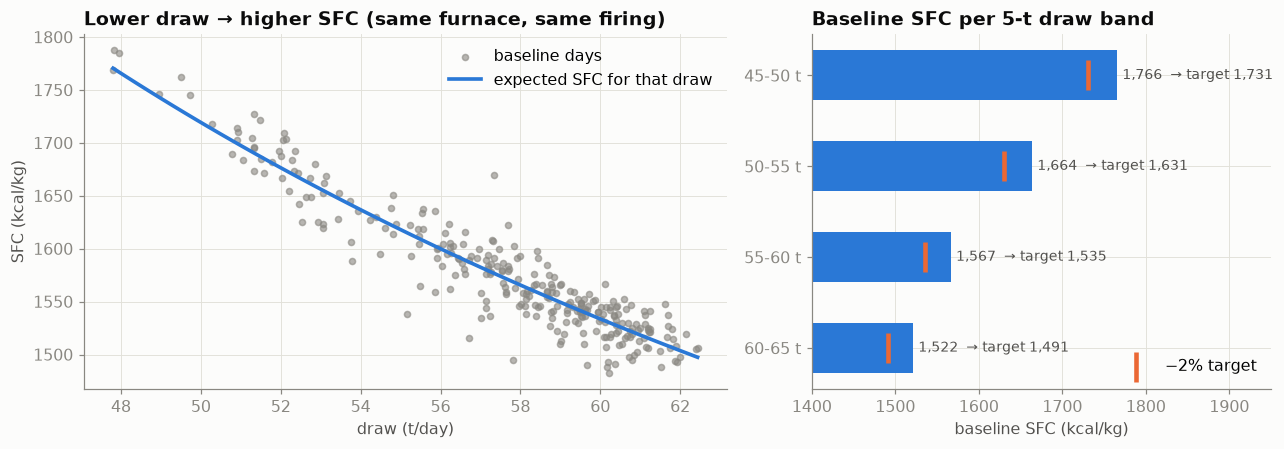

Energy = 55.7 Gcal/day fixed + 0.605 Gcal per tonne drawn  ->  62% of the energy is fixed
So +1 t/day of draw lowers SFC by about 1.1%


In [4]:
R.chart_draw(D)
k = D.mA.params
fixed = k.Intercept + k.cullet_pct * D.base.cullet_pct.mean()
print('Energy = %.1f Gcal/day fixed + %.3f Gcal per tonne drawn  ->  %.0f%% of the energy is fixed' % (fixed, k.draw_t, 100 * fixed / D.base.E_g.mean()))
print('So +1 t/day of draw lowers SFC by about %.1f%%' % (100 * fixed / D.base.E_g.mean() / D.base.draw_t.mean() * 1))

**What it means**
- About **60% of the furnace's energy is fixed**, so **+1 t/day of draw ≈ −1% SFC**.
- Moving from the 50–55 t band to the 60–65 t band lowers SFC by about 9% without any change in firing.
- That is why results must be judged **per draw band** or **draw-adjusted**, never on raw monthly SFC. The chart on the right shows each band's baseline and its −2% target.

---
## 4. Insight 3 — Judge performance fairly: draw-adjusted
The **draw-adjusted %** compares each day's energy with what the baseline period needed **at the same draw and cullet**:

`expected energy (Gcal/day) = 53.55 + 0.605 × draw (t) + 0.123 × cullet (%)`, fitted on the 286 usable baseline days

`draw-adjusted % = actual energy ÷ expected energy − 1`

*Example:* on 29 Jul 2026 the draw was only 49.7 t. Raw SFC (1,745) looks 10.7% worse than the baseline, but the furnace used only 0.96% more energy than the baseline would have at that draw.

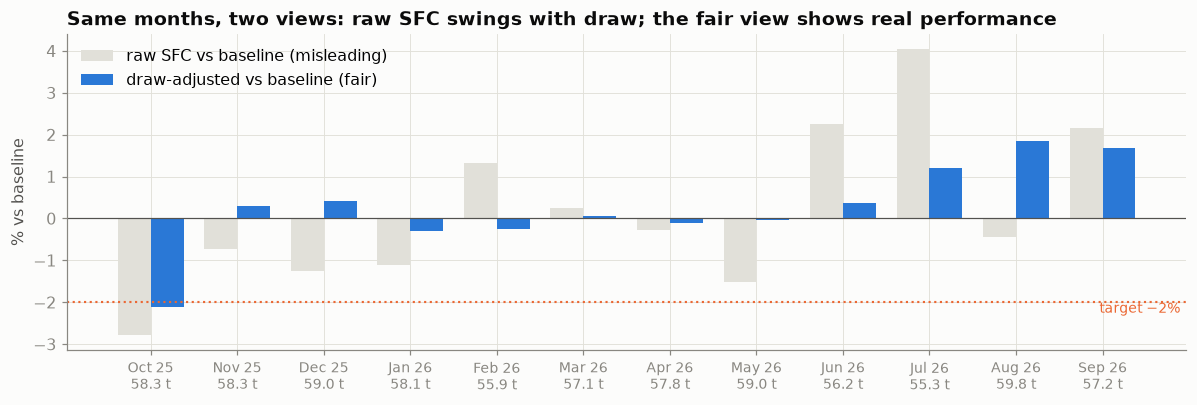

,draw (t/day),SFC,raw vs baseline %,draw-adjusted %
date,,,,
2025-10,58.29,1532.31,-2.79,-2.11
2025-11,58.33,1564.92,-0.72,0.29
2025-12,59.01,1556.53,-1.25,0.42
2026-01,58.11,1558.96,-1.10,-0.29
2026-02,55.88,1597.04,1.32,-0.26
2026-03,57.11,1580.34,0.26,0.06
2026-04,57.82,1571.85,-0.28,-0.11
2026-05,58.96,1552.58,-1.50,-0.03
2026-06,56.17,1611.94,2.26,0.37


In [5]:
R.chart_raw_vs_adjusted(D)

**What it means**
- **Jun and Jul 2026** look 2–4% "worse" on raw SFC, mostly because of lower draw. Draw-adjusted, they are +0.4% and +1.2%.
- **Aug 2026** looks fine on raw SFC because the draw was high, but draw-adjusted it is +1.8%.
- So the fair view shows real performance in both directions. **The −2% target is a −2% on the blue bars.**

---
## 5. Insight 4 — Furnace ageing is a slow headwind
At the same draw, the furnace needs slightly more energy every month. This is normal wear of the refractory and regenerators.

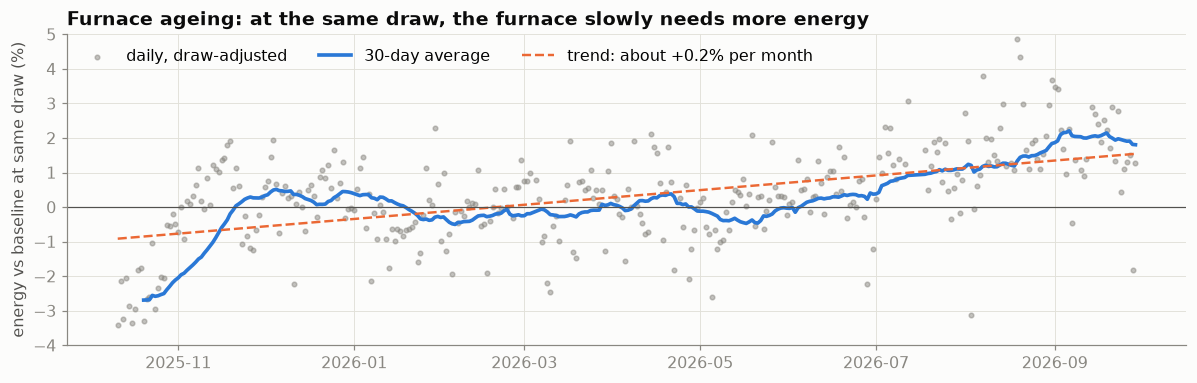

Ageing at the same draw: +0.19% energy per month (statistically significant, p = 0.000)
Jun-Aug 2026, draw-adjusted: +1.14% vs the baseline


In [6]:
R.chart_ageing(D)
mB = D.mB
print('Ageing at the same draw: %+.2f%% energy per month (statistically significant, p = %.3f)' % (100 * mB.params.age_m / D.base.E_g.mean(), mB.pvalues.age_m))
print('Jun-Aug 2026, draw-adjusted: %+.2f%% vs the baseline' % D.u.loc['2026-06':'2026-08'].draw_adj.mean())

**What it means**
- Energy rises by about **0.19% per month** at the same draw.
- By summer 2026 the furnace was about **+1.1% above the baseline** at the same draw. So **−2% vs the baseline is about −3% vs today's operation**.
- Ageing is not caused by operators. Section 11 explains how it is handled in the success measurement.

---
## 6. Insight 5 — Gas quality changes every 15 minutes, and gas flow follows it late
When NCV rises, each SCM of gas carries more heat, so the gas flow should drop by the same proportion to keep the heat steady. The chart shows one day with typical NCV swings.

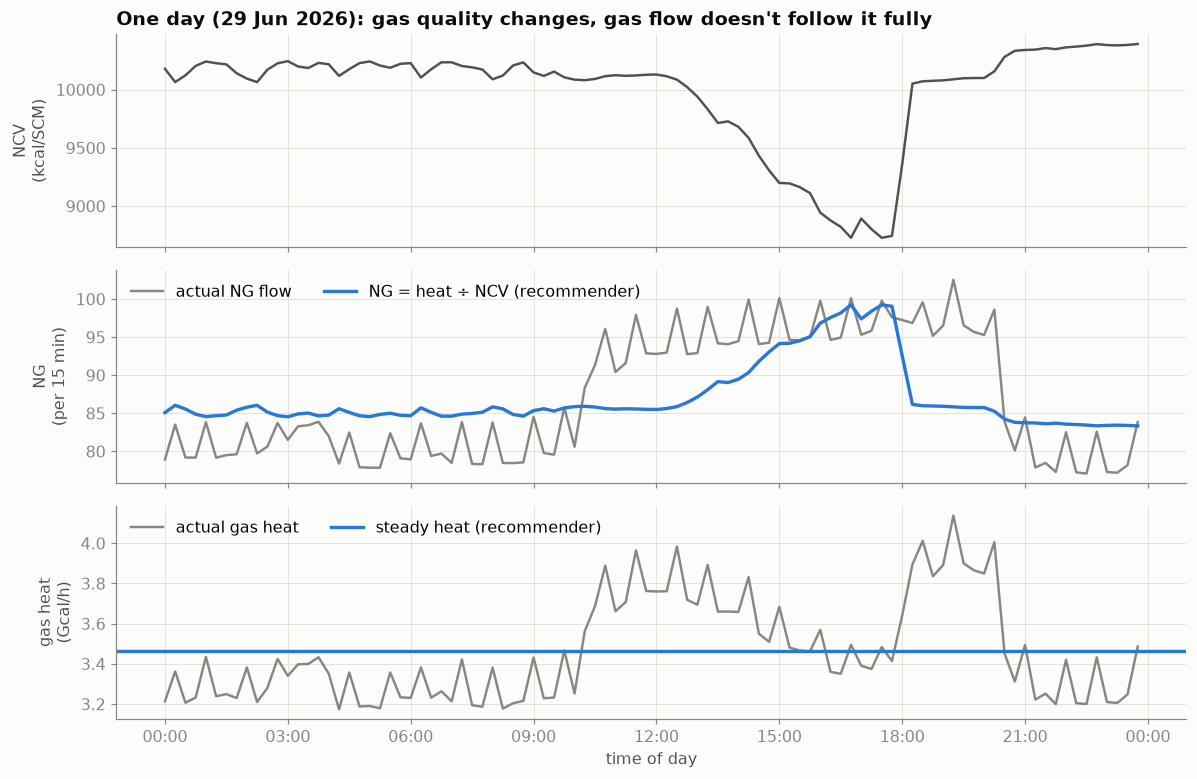

In [7]:
R.chart_ncv_day(D, '2026-06-29')

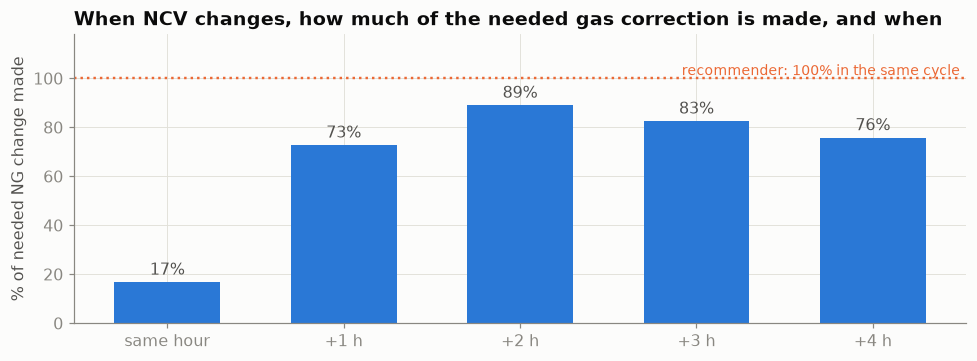

In [8]:
R.chart_ncv_lag(D)

**What it means**
- In the same hour, only about **17%** of the needed gas change is made. After one hour about **73%**, after two hours about **89%**. Meanwhile the furnace gets too much heat when NCV rises and too little when it falls.
- Too much heat is wasted energy; too little heat is usually made up later with extra margin.
- **The gas recommender sets `NG = needed heat ÷ latest NCV` every reversal cycle**, so the correction is 100% straight away and the heat stays steady.

---
## 7. Insight 6 — Barrier boost controls the bottom temperature, but it doesn't save energy
- **How it works:** barrier-boost electrodes sit low in the melter and heat the glass from below. The MB3 thermocouple in the bottom sees this directly. Gas burns above the glass, and little of its heat reaches the bottom quickly.
- **What we measured:** the response of MB3 to a step in barrier boost, from your hourly data (a distributed-lag model, which separates the furnace's response from operators' reactions).

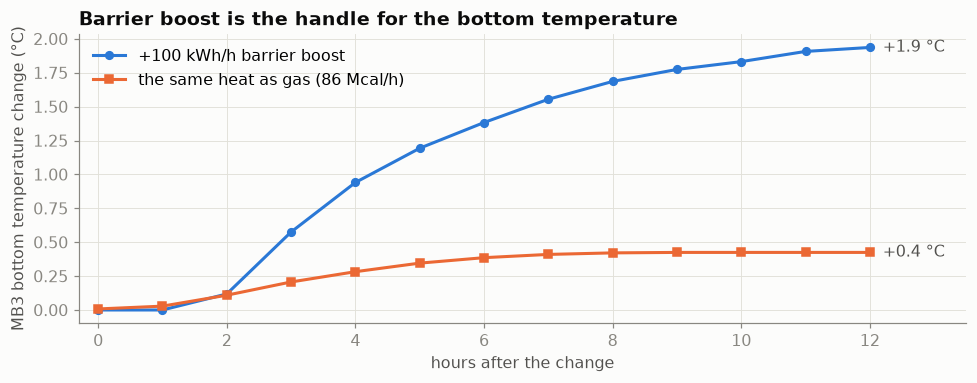

In [9]:
R.chart_boost_mb3(D)

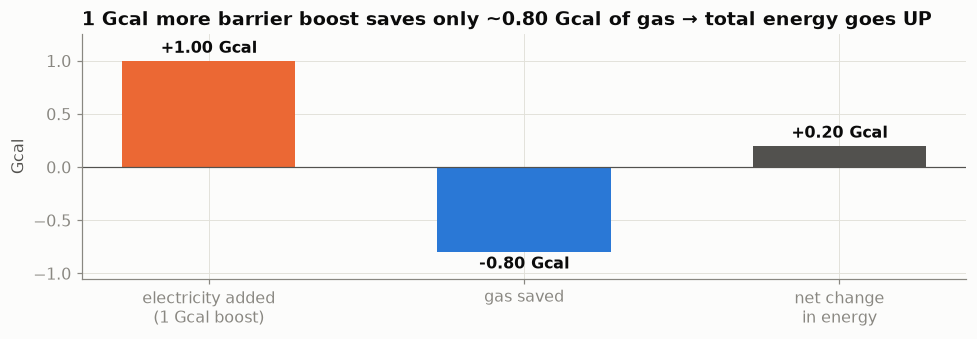

In [10]:
R.chart_boost_energy(D)

**What it means**
1. **Barrier boost is the right handle for the bottom temperature.** +100 kWh/h raises MB3 by about 1.9 °C over 6–12 hours. The same heat as gas moves it only about 0.4 °C.
2. **But boost doesn't replace gas one-for-one.** Each extra Gcal of boost saves only about 0.8 Gcal of gas (after allowing for ageing), so **total energy goes up** when boost goes up.
3. **So the right use is the minimum boost that holds MB3 at its normal level.**
   - In Jun–Aug 2026, MB3 ran about 1.5 °C *above* its historical median, so more boost was used than needed.
   - In Sep 2026 it ran slightly below, so a little more boost was needed.
   - The boost recommender handles both directions.

---
## 8. Insight 7 — Less excess air, less energy
Secondary air must supply the oxygen for combustion, and oxygen demand follows the **heat** burned. Any extra air is heated up and leaves through the regenerators and flue, carrying energy away. We grouped days by their air per Mcal and compared their energy at the same draw and furnace age.

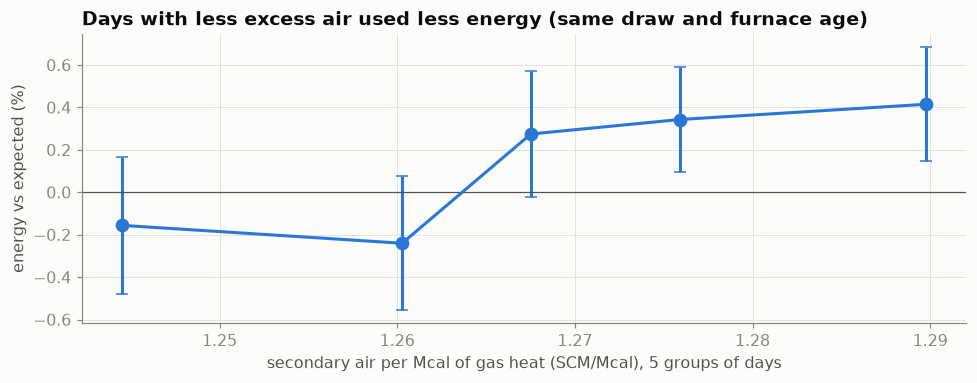

In [11]:
R.chart_air(D)

**What it means**
- Days with less air per Mcal used measurably less energy, within the range the furnace has already run at.
- **There is no O₂ analyser**, so the recommender never asks for less air than the furnace has already run at safely.
- Going further (lever B in section 11) needs a portable O₂/CO check during the trial.

---
## 9. Insight 8 — Glass quality is not at risk; efficient days are also good-quality days

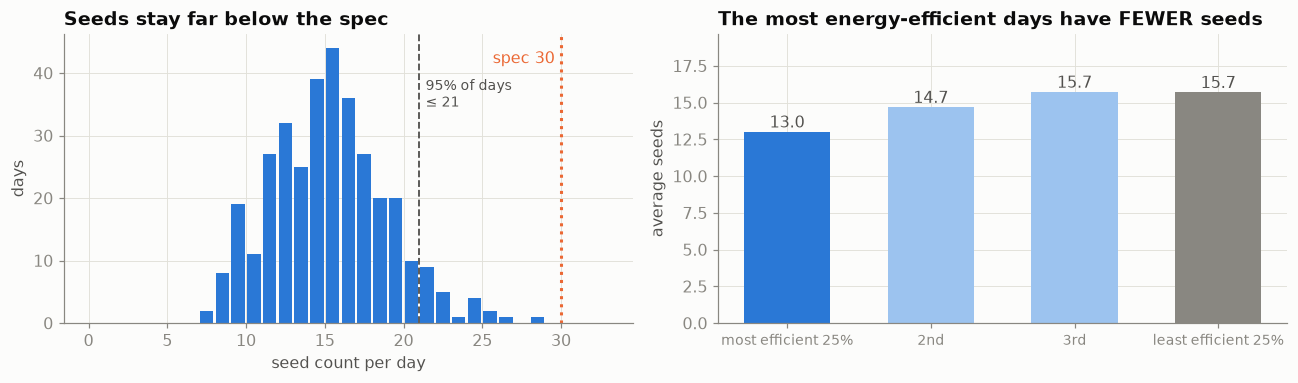

In [12]:
R.chart_seeds(D)

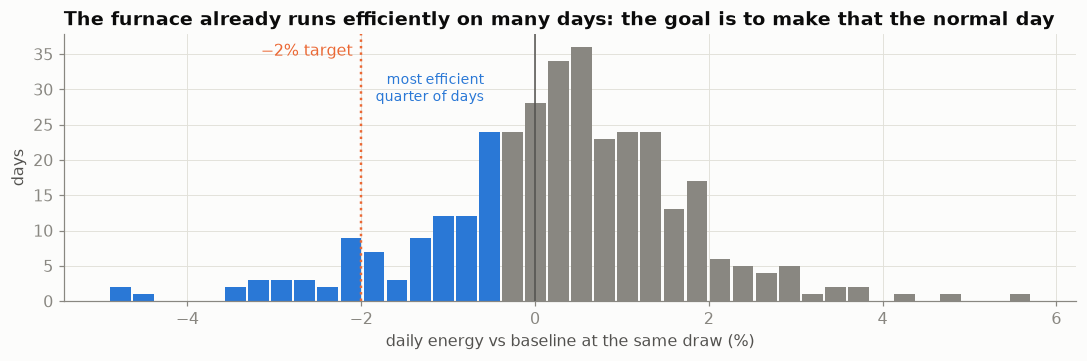

eff,most efficient 25%,least efficient 25%
energy vs baseline at same draw (%),-1.53,2.01
draw (t/day),57.62,57.96
air per Mcal,1.26,1.28
barrier boost (kWh/day),8750.29,8995.33
MB3 bottom temp (°C),1319.81,1321.06
optical crown temp (°C),1574.66,1574.15
seeds,13.01,15.70


In [13]:
R.chart_efficient_spread(D)
R.best_vs_worst(D)

**What it means**
- **Seeds** stay far below the spec of 30 (95% of days ≤ 21). The most energy-efficient days have **fewer** seeds, not more. Saving energy within the proven range does not hurt quality.
- **The most efficient quarter of days** (about 3.5% less energy than the least efficient quarter, at the same draw) used **less air per Mcal**, **less barrier boost** and a **cooler bottom (about −1.2 °C MB3)**. They had **fewer seeds**, and almost the same crown temperature.
- **Those efficient days already exist in your history.** The recommenders aim to make them the normal day.

---
## 10. What the recommenders do, and what they would have achieved
| | Gas recommender | Barrier-boost recommender |
|---|---|---|
| **When** | every 20-min reversal cycle, ready by minute 15 | every hour |
| **Uses** | latest NCV, draw, cullet, barrier and melter boost of the last hour; optical crown as a safety check | MB3 now, boost of the last hour |
| **Sets** | **NG flow** (one value for both ports), **secondary air**, **AFR** | **barrier boost** for the next hour |
| **Logic** | daily gas-heat target = what the most efficient quarter of comparable recent days needed (same draw, boost and furnace age), delivered evenly; NG = heat ÷ latest NCV; air = efficient air per Mcal × heat | small hourly correction toward the boost that holds MB3 at its normal level (historical median 1,320.25 °C) |
| **Limits** | NG, air and AFR within their historical P1–P99 | boost within 114–610 kWh/h (historical P1–P99) |

**How we know it works:** we replayed your history **walk-forward**. For every day from 1 Dec 2025 to 29 Sep 2026, the recommenders used only the days before it, as they would live. Then we compared the resulting SFC with what actually happened.

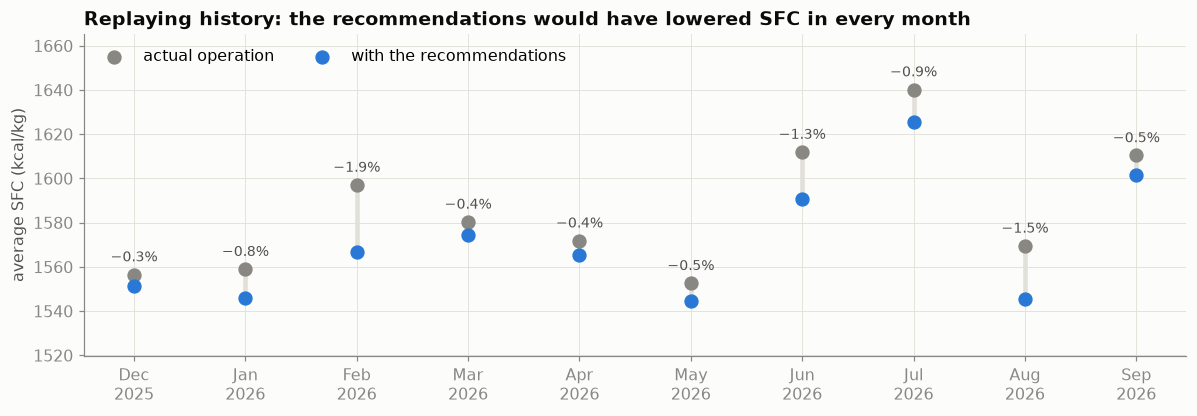

All 292 replayed days: SFC 1583.4 -> 1569.8 kcal/kg (0.86% lower); draw-adjusted +0.47% -> -0.40%


,actual SFC,with recommendations,days,saving %
date,,,,
2025-12,1556.53,1551.31,31,0.34
2026-01,1558.96,1546.09,31,0.83
2026-02,1597.04,1566.98,28,1.88
2026-03,1580.34,1574.49,29,0.37
2026-04,1571.85,1565.38,30,0.41
2026-05,1552.58,1544.82,31,0.50
2026-06,1611.94,1590.87,30,1.31
2026-07,1640.20,1625.43,25,0.90
2026-08,1569.50,1545.32,30,1.54


In [14]:
m = R.chart_monthly_replay(D)
bt = D.bt
print('All %d replayed days: SFC %.1f -> %.1f kcal/kg (%.2f%% lower); draw-adjusted %+.2f%% -> %+.2f%%' % (len(bt), bt.sfc_actual.mean(), bt.sfc_rec.mean(), 100 * (1 - bt.sfc_rec.mean() / bt.sfc_actual.mean()), bt.draw_adj_actual.mean(), bt.draw_adj_rec.mean()))
m.rename(columns={'actual': 'actual SFC', 'rec': 'with recommendations', 'saving': 'saving %'})

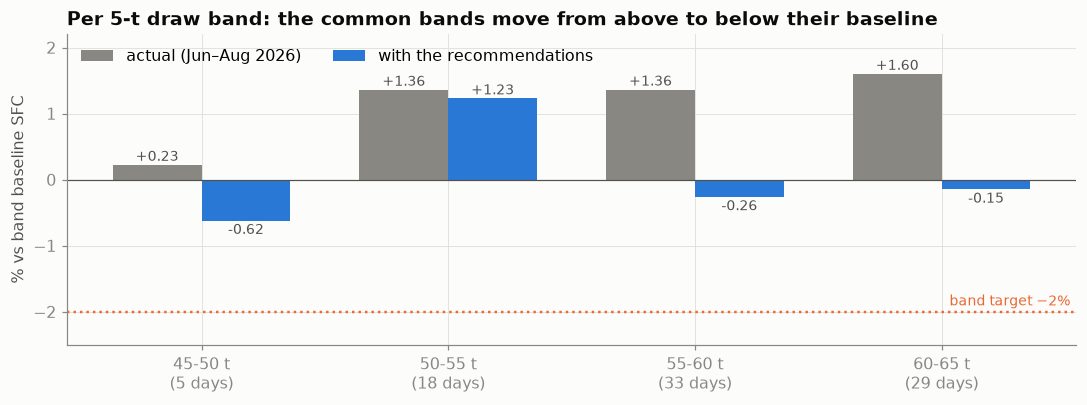

In [15]:
R.chart_bands(D)

**What it means**
- **SFC is lower in every month** of the replay: 0.3% to 1.9% lower, 0.9% on average, with every setpoint inside the historical limits.
- **Jun–Aug 2026** (the main test period): about **−1.3% SFC**. Draw-adjusted, the furnace moves from **+1.14%** above the baseline to **−0.17%**.
- **Per band:** the two most common bands (55–60 t and 60–65 t) move from about +1.5% *above* their baselines to *below* them.
- **The size of the saving depends on the month.** It is the avoidable loss that is there to remove. In Sep 2026 the bottom ran slightly cold, so the boost controller added a little boost, and the saving was 0.55%.

---
## 11. The path to −2%, and why a plant trial is needed
The recommenders work **inside the furnace's proven operating range**. That is what makes them safe, and it is also their limit: they can make every day as good as the furnace's good days, but they can't prove from history what happens beyond them. The remaining levers are small, controlled steps **just beyond** what the furnace usually does. Only a trial can measure them.

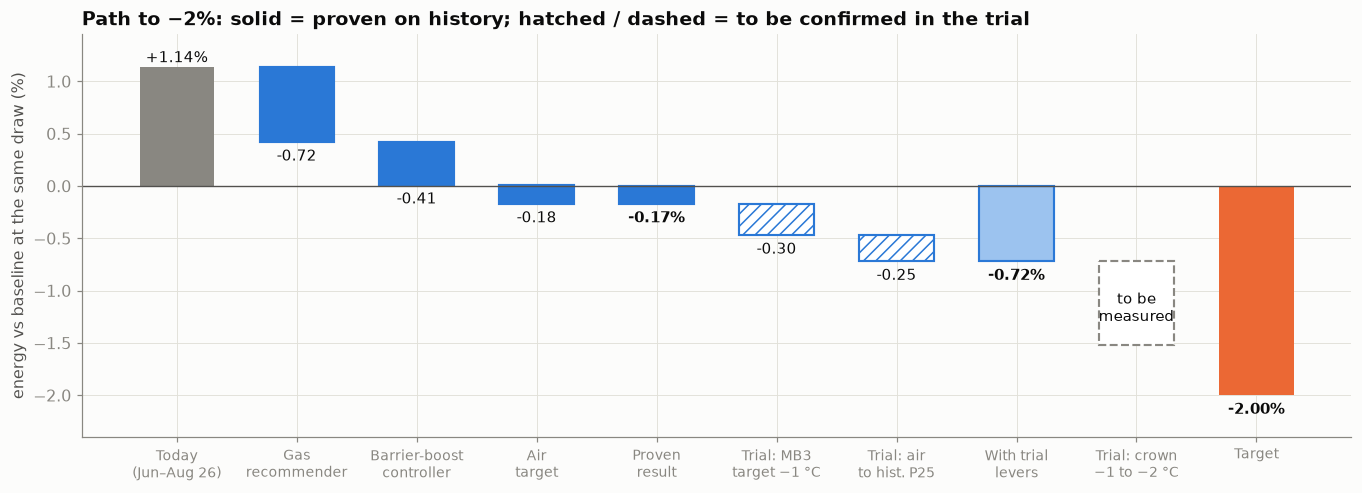

In [16]:
R.chart_path_to_2pct()

| Trial lever | Expected | Why it needs a trial |
|---|---|---|
| **A. Bottom temperature (MB3) target** from 1,320.25 °C toward 1,319.2 °C (still within history) | about −0.3% | Less boost; the effect on quality must be confirmed with daily seed checks |
| **B. Air per Mcal** toward the historical P25 (1.252) | about −0.25% | Needs a portable O₂/CO check (no analyser installed) |
| **C. Crown (optical) setpoint −1 °C, then −2 °C** | to be measured | The crown has always been held at ~1,574.5 °C, so history can't show the saving. Seeds have headroom (95% of days ≤ 21 vs spec 30) |
| **Draw** +1 t/day sustained | about −1% | A production decision, not a setpoint |

**Against the fixed baseline:** the furnace has aged about 1.1% since the baseline period. To reach −2% against the fixed baseline, the gap is closed by the levers above **plus** higher draw, maintenance, or an agreed adjustment for ageing in the success measurement (an ageing-adjusted baseline, a recognised adjustment for changes not caused by operation).

### How the trial proves the saving
- **Daily measurement** of draw-adjusted energy and band SFC, with the same formulas as above.
- **Trial length:** day-to-day noise is about 1.3%, so the average needs enough days to be reliable.

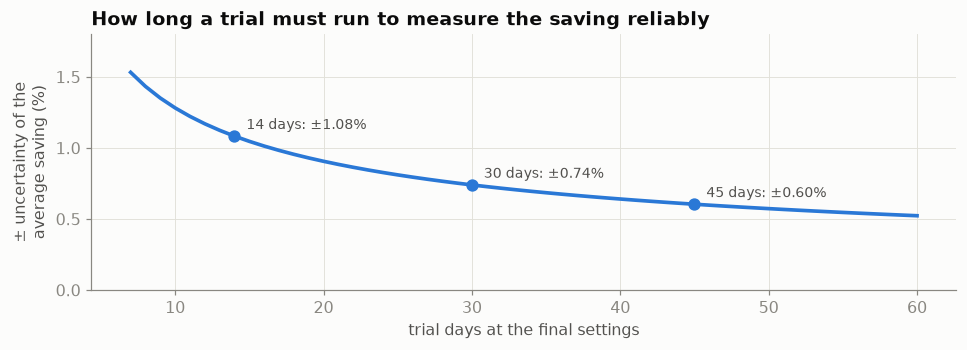

In [17]:
R.chart_mv_ci()

**30 trial days measure the saving to about ±0.74%** (95% confidence). Each phase therefore runs for at least 30 days.

| Phase | Weeks | What changes | Go / no-go |
|---|---|---|---|
| **0. Shadow mode** | 1–2 | Recommendations computed live and logged, **not applied**; data feeds checked | feeds complete; operators agree the values are sensible |
| **1. Gas + air** | 3–6 | NG and secondary air / AFR set from the recommender each reversal cycle | no guard-rail breach; draw-adjusted energy below Phase 0 |
| **2. + Barrier boost** | 7–10 | Barrier boost from the controller (MB3 target 1,320.25 °C) | MB3 within 1,317.6–1,323.9 °C ≥ 95% of hours; seeds normal |
| **3. Trial levers** | 11–14+ | One lever at a time, each ≥ 7 days: MB3 target, air, crown setpoint | guard-rails hold; keep each lever that shows a saving |
| **4. Lock-in** | after | Final settings become standard; ≥ 30 days of measurement | −2% criteria met |

**Daily guard-rails (any breach → go back one step):**
- seeds > 21 on 2 days in a row, or any day > 25
- MB3 outside 1,317.6–1,323.9 °C for more than 3 hours
- optical crown below 1,570 °C
- crown thermocouple more than 3 °C below its previous-week average
- every operator override logged with its reason

---
## 12. Summary
| Question | Answer |
|---|---|
| Is the baseline right? | **Yes**: 1,576.6 from raw data vs 1,576.3 stated. Target 1,544.8 |
| What drives SFC? | **Draw** (+1 t/day ≈ −1%), **ageing** (+0.19%/month) and **how gas, air and boost are set** |
| Where is energy lost today? | Gas corrected late after NCV changes; more barrier boost than needed; a little more air than on the best days |
| Is quality at risk? | **No**: seeds far below spec, and efficient days have fewer seeds |
| What do the recommenders deliver? | Lower SFC in **every month** of the replay; **−1.3%** in Jun–Aug 2026; draw-adjusted **+1.14% → −0.17%**; all setpoints inside proven limits |
| How do we get to −2%? | Recommenders **+** trial levers (MB3 target, air with O₂ check, crown setpoint) **+** draw / ageing handling |
| What is needed from the plant? | Approval of the **phased trial**, a portable **O₂/CO analyser** for lever B, official limits for MB3 / crown / electrodes if tighter than history, and agreement on the success yardstick (band or draw-adjusted, and the treatment of ageing) |

The second notebook, **`02_model_training_and_recommender.ipynb`**, shows how the recommenders were built and tested. It ends with the recommendation function: enter current plant values and get the setpoints.